# A case study using the "out-of-sample" 2026 MAM season

Find three locations, one a clear trigger, one a clear miss, and one within the CI

In [1]:
import xarray as xr
from xarray.groupers import SeasonResampler
import xagg as xa
import xesmf as xe
import numpy as np
import pandas as pd 
import geopandas as gpd
import os
import glob
import string
import re
from matplotlib import pyplot as plt
from matplotlib import patches as mpatches
from matplotlib.gridspec import GridSpec
import matplotlib as mpl
from cartopy import crs as ccrs
import shapely
import cmocean
from dask.diagnostics import ProgressBar
from numba import jit as njit
from distributed import Client

from funcs_support import get_params,get_filepaths, utility_print, utility_save, load_data
from funcs_aux import get_landmask
from funcs_plot import add_colorbar

dir_list = get_params()

mpl.font_manager.fontManager.addfont(dir_list['aux'] + "fonts/Lato-Regular.ttf")
mpl.font_manager.fontManager.addfont(dir_list['aux'] + "fonts/Lato-Bold.ttf")

mpl.rcParams.update({
    "font.family": "Lato",
})

subplot_lettering = string.ascii_lowercase #string.ascii_lowercase

In [2]:
client = Client()
display(client)

/home/kschwarz/.conda/envs/aa_thresh/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 43727 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:43727/status,
Dashboard: http://127.0.0.1:43727/status,Workers: 8
Total threads: 48,Total memory: 503.54 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40255,Workers: 0
Dashboard: http://127.0.0.1:43727/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36755,Total threads: 6
Dashboard: http://127.0.0.1:46401/status,Memory: 62.94 GiB
Nanny: tcp://127.0.0.1:43533,


In [3]:
# Variables / bootstrap dimension setup
boot_dim = 'year'
var = 'pr'

# Which data to use
# GPCP, CHIRPS, or NCEP-CFSv2 / NCEP-CFSv2-ensmean
proc_source = 'NCEP-CFSv2-ensmean' 
#proc_source = 'GPCP'

# Set output filenames
load_fns = {'threshs':dir_list['tmp']+'pr-trigger-threshs_year_'+proc_source+'.zarr',
              'seasmask':dir_list['aux']+'seasmask_CHIRPS.zarr'}

df = get_filepaths(source_dir = 'raw')

In [4]:
# Load calculated trigger thresholds
threshs = xr.open_zarr(load_fns['threshs'])
threshs['triggrange_bnds'] = xr.concat([threshs['triggthresh'].quantile(0.025,dim='draw'),
                                        threshs['triggthresh'].quantile(0.975,dim='draw')],
                                       dim='bnds')

In [5]:
#-------------------------------------
# Get threshold-based dry season mask
#-------------------------------------
seas_thresh = 0.5 # mm/day

# Load data
dsm = load_data(proc_source,data='seasavg')

# Get boolean mask for threshold exceedence
dry_thresh = dsm.pr.mean('year')>seas_thresh

# Get landmask
landmask = get_landmask(threshs,lm_source='ne110')

# Get country borders
gdf = gpd.read_file(dir_list['aux']+'geo_data/ne_10m_admin_0_countries_iso/ne_10m_admin_0_countries_iso.shp')

# Get mask for if there's an active season locally
active_seasons = xr.open_zarr(load_fns['seasmask'])
# Regrid seasonmask to trigger threshold grid
rgrd = xe.Regridder(active_seasons,threshs,'conservative')
active_seasons_rg = rgrd(active_seasons)
active_seasons_rg = active_seasons_rg.sel(lat=threshs.lat.values)

subset_params = {'lat':slice(-35,35),'lon':slice(-180,180)}

seas_mask = (active_seasons_rg.seasmask.sel(**subset_params) & 
                   dry_thresh).where(landmask).compute()

lat/lon bounds not found in dataset; they will be created.


/home/kschwarz/.conda/envs/aa_thresh/lib/python3.13/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 13.44 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [6]:
# Load 2026 forecast
ds2026 = xr.open_dataset(df.query(f'model == "{proc_source}" and time == "20260101-20260731"').iloc[0]['path'])
ds2026 = ds2026.isel(lead=0).sel(time=slice('2026-03-01','2026-05-31')).mean('time')

ds2026 = ds2026.where(seas_mask.sel(season='MAM')).where(landmask)

dsm['pr26'] = ds2026.pr


### Diagnostic map of which locations have clear / unclear triggers for 2026 MAM

In [7]:
# Load trigger range for ease
triggrange = threshs.triggrange_bnds.sel(season='MAM').load()

# Get locations within or without CI
locs = xr.concat([ds2026.pr > triggrange.max('bnds'),
                  ds2026.pr < triggrange.min('bnds'),
                  ((ds2026.pr >= triggrange.min('bnds')) & 
                   (ds2026.pr <= triggrange.max('bnds')))],
                 dim=pd.Index(['notrigger','cleartrigger','posstrigger'],
                              name='typ'))

locs_ = (xr.zeros_like(locs.isel(typ=0)).where(~locs.sel(typ='notrigger'),1).
                                         where(~locs.sel(typ='posstrigger'),2).
                                         where(~locs.sel(typ='cleartrigger'),3))
locs_ = locs_.where(locs_>0)

/home/kschwarz/projects/forecast_uncertainty/2. figures/MAM2026_trigger_map_blength5.pdf saved!
/home/kschwarz/projects/forecast_uncertainty/2. figures/MAM2026_trigger_map_blength5.png saved!


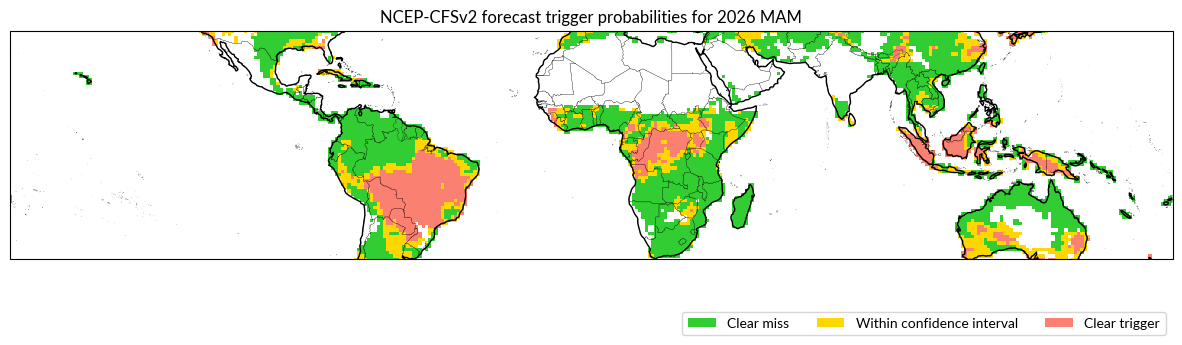

In [580]:
# Figure showing 2026 trigger forecast by whether it's in the CI or not

block_length = 5

save_fig = True
output_fn = f'{dir_list['figs']}MAM2026_trigger_map_blength{block_length}'
fig = plt.figure(figsize=(15,4))
ax = plt.subplot(projection=ccrs.PlateCarree())
locs_.sel(block_nyears = block_length).plot(levels=[0.5,1.5,2.5,3.5],transform=ccrs.PlateCarree(),
                                            colors = ['limegreen','gold','salmon'],add_colorbar=False)
ax.coastlines()

ax.set_title('NCEP-CFSv2 forecast trigger probabilities for 2026 MAM')

gdf.cx[subset_params['lon'],subset_params['lat']].plot(ax=ax,facecolor='none',edgecolor='k',
                                                           linestyle='-',linewidth=0.15,
                                                           transform=ccrs.PlateCarree())
ax.set_extent([subset_params['lon'].start,
               subset_params['lon'].stop,
               subset_params['lat'].start,
               subset_params['lat'].stop])

ax.legend([mpatches.Patch(fc=col) for col in ['limegreen','gold','salmon']],
          ['Clear miss','Within confidence interval','Clear trigger'],
          bbox_to_anchor = (1,-0.2),ncol=3)

if save_fig:
    utility_print(output_fn)

## Case study maps setup

In [8]:
# Load ADM0 / ADM1 shapefiles. Note that Natural Earth only has ADM1 shapefiles
# for a few regions; get the rest from HumData, e.g., 
# https://data.humdata.org/dataset/geoboundaries-admin-boundaries-for-ethiopia
# for Ethiopia. 
adm1 = gpd.read_file('../aux_data/geo_data/ne_50m_admin_1_states_provinces/ne_50m_admin_1_states_provinces.shp')
shp_lists = glob.glob(dir_list['aux']+'geo_data/geoBoundaries*')
adm0_dict = {'SOM':'Somalia',
             'PRY':'Paraguay',
             'ETH':'Ethiopia'}
for fn in shp_lists:
    gdf_tmp = gpd.read_file(fn).rename({'shapeName':'name','shapeISO':'adm1_code','shapeTYPE':'gadm_level',
                                    'shapeGroup':'adm0_a3'},axis=1)
    gdf_tmp['admin'] = adm0_dict[re.split(r'\-',re.split(r'\/',fn)[-1] )[1]]
    gdf_tmp['iso_a2'] = [re.split(r'\-',k)[0] for k in gdf_tmp['adm1_code'].values]
    adm1 = pd.concat([adm1,gdf_tmp])

# Add "region" to Somali region in Ethiopia, for clarity
adm1.loc[adm1.name == 'Somali','name'] = 'Somali Region'

In [9]:
# Merge together seasonal mean precip with trigger threshold data
plot_data_all = xr.merge([dsm.sel(season='MAM'),
                          # Renamed bnds-edges, otherwise variable is dropped by xagg
          threshs[['triggrange_bnds','triggrange','threshmean']].sel(season='MAM').rename({'bnds':'edges'})],
                         compat='no_conflicts').load()

# Aggregate to adm1 regions
wm = xa.pixel_overlaps(plot_data_all,adm1)
with xa.set_options(impl='numba',silent=True):
    plot_data_agg = xa.aggregate(plot_data_all,wm)
    plot_data_agg = plot_data_agg.to_dataset()

    plot_data_agg = plot_data_agg.set_index(poly_idx='adm1_code')

creating polygons for each pixel...
lat/lon bounds not found in dataset; they will be created.
calculating overlaps between pixels and output polygons...
success!


/home/kschwarz/.conda/envs/aa_thresh/lib/python3.13/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 11.42 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/home/kschwarz/.conda/envs/aa_thresh/lib/python3.13/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 10.08 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [27]:
def plot_case_study(sample_locs,
                    plot_data_all,
                    plot_data_agg,
                    adm1,
                    block_length=5,
                    yr=None,
                    gdf=gdf,seas_mask=seas_mask,
                    subset_params=subset_params,
                    dry_seas_mask_color='lightgrey',
                    save_fig = False,
                    output_fn = None,
                    ):

    if len(sample_locs)>1:
        fig = plt.figure(figsize=(20,len(sample_locs)*4+0.25))
        title_fontsize=18
    else:
        fig = plt.figure(figsize=(18,len(sample_locs)*4+0.25))
        title_fontsize=15
        
    gs = GridSpec(len(sample_locs)+1, 6, width_ratios = [0.385,*[1]*5],height_ratios = [0.05,*[1]*len(sample_locs)])
    
    
    
    col0_axs = []
    botrow_axs = []
    row_names = []
    for row_idx,sample_loc in enumerate(sample_locs):
    
        sample_point = shapely.Point(sample_locs[sample_loc]['lon'],
                  sample_locs[sample_loc]['lat'])
        adm1_tmp = adm1.loc[adm1.contains(sample_point),:]
        loc_code = adm1_tmp.adm1_code.values[0]
        adm1_parent= adm1_tmp.iso_a2.values[0]
        adm0_tmp = adm1.query(f'iso_a2 == "{adm1_parent}"')

        if yr is None:
            map_datas = [(plot_data_all.pr26 - plot_data_all.pr.mean('year')) / plot_data_all.pr.std('year'),
                         (plot_data_all.pr26 - plot_data_all.threshmean).sel(block_nyears=block_length) / plot_data_all.pr.std('year'),
                         (plot_data_all.triggrange / plot_data_all.pr.std('year')).sel(block_nyears=block_length)]
        else:
            map_datas = [(plot_data_all.pr.sel(year=yr) - plot_data_all.pr.mean('year')) / plot_data_all.pr.std('year'),
                     (plot_data_all.pr.sel(year=yr) - plot_data_all.threshmean).sel(block_nyears=block_length) / plot_data_all.pr.std('year'),
                     (plot_data_all.triggrange / plot_data_all.pr.std('year')).sel(block_nyears=block_length)]
        cmap_params = [{'cmap':cmocean.cm.balance_r,'vmin':-2.5,'vmax':2.5},
                       {'cmap':cmocean.cm.curl_r,'vmin':-2.5,'vmax':2.5},
                       {'cmap':cmocean.cm.matter,'vmin':0,'vmax':1.5}]
        if yr is None:
            labels = ['2026 MAM\n'+r'$P$ anomalies [zscore]',
                  'Difference between 2026 MAM '+r'$P$'+'\nand mean trigger threshold '+r'[$\sigma$]',
                  '95% bootstrap range of\ntrigger thresholds '+r'[$\sigma$]']
        else:
            labels = [f'{yr} MAM\n'+r'$P$ anomalies [zscore]',
              f'Difference between {yr} MAM '+r'$P$'+'\n and  mean trigger threshold '+r'[$\sigma$]',
              '95% bootstrap range of\ntrigger thresholds '+r'[$\sigma$]']
        
        # ------ Subplot 1-3: anomaly maps
        for col_idx in range(len(map_datas)):
            ax = fig.add_subplot(gs[row_idx+1,col_idx+1],projection=ccrs.PlateCarree())
            # ------ Location lettering at left and colorbar at bottom
            if col_idx == 0:
                col0_axs.append(ax)
                loc_text = adm1_tmp.name.values[0]
                if loc_text.isupper():
                    # Some of these are all-uppercase
                    loc_text = loc_text.title()
                loc_text = f'{loc_text},\n {adm1_tmp.admin.values[0]}'
                row_names.append(loc_text)
            if row_idx == len(sample_locs)-1:
                botrow_axs.append(ax)
                
    
            # ------ Mapsa
            # Plot ADM1s of the ADM0 used
            (adm0_tmp.clip((subset_params['lon'].start,subset_params['lat'].start,
                           subset_params['lon'].stop,subset_params['lat'].stop)).
                plot(ec = 'k',fc='none',transform=ccrs.PlateCarree(),ax=ax,zorder=2))
            
            # Get aspect for square plot
            ext = ax.get_extent()
            sqext = np.max([[ext[1]-ext[0]],
                           [ext[3]-ext[2]]])
            ext = [np.mean(ext[0:2])-sqext/2,
                   np.mean(ext[0:2])+sqext/2,
                   np.mean(ext[2:4])-sqext/2,
                   np.mean(ext[2:4])+sqext/2]
            
            # Plot other ADM0s
            gdf.cx[ext[0]:ext[1],ext[2]:ext[3]].plot(ax=ax,
                                                     ec = 'k',lw=1.5,
                                                     fc='none',transform=ccrs.PlateCarree(),
                                                     zorder=1)
            
            # Plot sample ADM0
            adm1_tmp.plot(fc='none',ec='yellow',lw=2,ax=ax,transform=ccrs.PlateCarree(),zorder=3)
            
            # Plot data
            (map_datas[col_idx].
                where(landmask).
                sel(lat=slice(ext[2]-1,ext[3]+1),
                    lon=slice(ext[0]-1,ext[1]+1)).
                plot(zorder=0,
                     transform=ccrs.PlateCarree(),
                     **cmap_params[col_idx],
                     add_colorbar=False))
            # Grey out regions without an active rainy season or that are generally  too dry
            seas_mask.sel(season='MAM').plot(levels=[-0.5, 0.5, 1.5],
                                         colors=[dry_seas_mask_color,'none'],
                                         transform=ccrs.PlateCarree(),
                                         add_colorbar=False,zorder=0)
            
            # Make aspect square
            ax.set_extent(ext)
            
            if row_idx == 0:
                ax.set_title(labels[col_idx],fontsize=title_fontsize,fontweight='bold')
            else:
                ax.set_title('')
    
            ax.annotate(subplot_lettering[row_idx*5+col_idx],(0.025,0.975),xycoords = 'axes fraction',
                            fontweight='bold',fontsize=15,va='top',ha='left',
                        bbox={'boxstyle':'round','alpha':0.8,
                                     'ec':'none','fc':'white'})
        
        # ------ Subplot 4: time series
        ax = fig.add_subplot(gs[row_idx+1,4])
        
        plot_data_agg.sel(poly_idx=loc_code).pr.plot(color='tab:blue',lw=2)
        if yr is None:
            plt.plot(2026,
                        plot_data_agg.sel(poly_idx=loc_code).pr26,
                        'x',color='tab:blue')
            # Also add dotted line between 2025 and 2026
            plt.plot([2025,2026],
                     [plot_data_agg.sel(poly_idx=loc_code,year=2025).pr,
                      plot_data_agg.sel(poly_idx=loc_code).pr26],
                     linestyle='--',color='tab:blue')
        else:
            plt.plot(yr,
                    plot_data_agg.sel(poly_idx=loc_code,year=yr).pr,
                    'o',color='tab:blue',markersize=7.5,zorder=3,label=f'{yr} MAM')
        
        ax.axhline(plot_data_agg.sel(poly_idx=loc_code).pr.quantile(0.2),
                   color='r',label=f'20% trigger {plot_data_all.year.values[0]}-{plot_data_all.year.values[-1]}')
        
        ax.axhspan(plot_data_agg.triggrange_bnds.sel(poly_idx=loc_code,block_nyears=block_length).isel(edges=0),
                   plot_data_agg.triggrange_bnds.sel(poly_idx=loc_code,block_nyears=block_length).isel(edges=1),
                   color='beige',label='95% bootstrap trigger range')
        
        ax.set_xlabel('')
        #ax.set_ylabel(r'$P$ [mm/day]')
        ax.set_ylabel('')
        if row_idx == 0:
            ax.set_title(r'MAM $P$ [mm/day]',fontsize=title_fontsize,fontweight='bold')
        else:
            ax.set_title('')
    
        if row_idx == 0:
            ax.legend(loc='upper right')
        
        ax.annotate(subplot_lettering[row_idx*5+3],(0.025,0.975),xycoords = 'axes fraction',
                            fontweight='bold',fontsize=15,va='top',ha='left',
                        bbox={'boxstyle':'round','alpha':0.8,
                                     'ec':'none','fc':'white'})
        
        # ------ Subplot 5: CDF
        ax = fig.add_subplot(gs[row_idx+1,5])
        plt.plot(np.sort(plot_data_agg.sel(poly_idx=loc_code).pr),
                 np.arange(0,plot_data_agg.sizes['year'])/plot_data_agg.sizes['year'],
                 color='k',label=f'{plot_data_all.year.values[0]}-{plot_data_all.year.values[-1]} CDF')

        if yr is None:
            ax.axvline(plot_data_agg.sel(poly_idx=loc_code).pr26,
                   color='tab:blue',linestyle='--',label='2026 MAM')
        else:
            ax.axvline(plot_data_agg.sel(poly_idx=loc_code,year=yr).pr,
                   color='tab:blue',linestyle='--',label=f'{yr} MAM',lw=2)
        ax.axvline(plot_data_agg.sel(poly_idx=loc_code).pr.quantile(0.2),
                   color='r')
        
        ax.axvspan(plot_data_agg.triggrange_bnds.sel(poly_idx=loc_code,block_nyears=block_length).isel(edges=0),
                   plot_data_agg.triggrange_bnds.sel(poly_idx=loc_code,block_nyears=block_length).isel(edges=1),
                   color='beige')
    
        ax.set_ylim([0,1])
    
        if row_idx == len(sample_locs)-1:
            ax.set_xlabel(r'$P$ [mm/day]',fontsize=18)
        else:
            ax.set_xlabel('')
        #ax.set_ylabel('Year rank')
        if row_idx == 0:
            ax.set_title(r'CDF of $P$',fontsize=title_fontsize,fontweight='bold')
        else:
            ax.set_title('')
    
        if row_idx == 0:
            ax.legend()
    
        ax.annotate(subplot_lettering[row_idx*5+4],(0.025,0.975),xycoords = 'axes fraction',
                            fontweight='bold',fontsize=15,va='top',ha='left',
                        bbox={'boxstyle':'round','alpha':0.8,
                                     'ec':'none','fc':'white'})
    
    plt.tight_layout()
    # Location labeling at left
    for ax,loc_text in zip(col0_axs,row_names):
        if len(sample_locs) == 1:
            locname_pos = (ax.get_position().x0-0.025*ax.get_position().width,
                           ax.get_position().y0+0.5*ax.get_position().height)
        else:
            locname_pos = (ax.get_position().x0-0.065*ax.get_position().width,
                           ax.get_position().y0+0.5*ax.get_position().height)
            
        # This messes up plt.tight_layout() unfortunately. Doing it after 
        # tight_layout() and fudging around until it doesn't mess with the
        # subplot positions too much
        plt.annotate(loc_text,
                    locname_pos,
                    xycoords = 'figure fraction',ha='right',va='center',
                    fontweight='bold',fontsize=18)
    
    # Colorbars at bottom
    for ax,cb in zip(botrow_axs,cmap_params):
        axpos = ax.get_position()
        if len(sample_locs) == 1:
            cb_pos = [axpos.x0,axpos.y0-0.125*axpos.height,axpos.width,0.05]
        else:
            cb_pos = [axpos.x0,axpos.y0-0.125*axpos.height,axpos.width,0.025]
        cb=add_colorbar(cb,orientation='horizontal',
                 axpos=cb_pos,
                 fig=fig)
        cb.ax.tick_params(labelsize=12)
    
    if save_fig:
        utility_print(output_fn)

## 2026 case studies

/home/kschwarz/projects/forecast_uncertainty/2. figures/case_studies_2026.pdf saved!
/home/kschwarz/projects/forecast_uncertainty/2. figures/case_studies_2026.png saved!


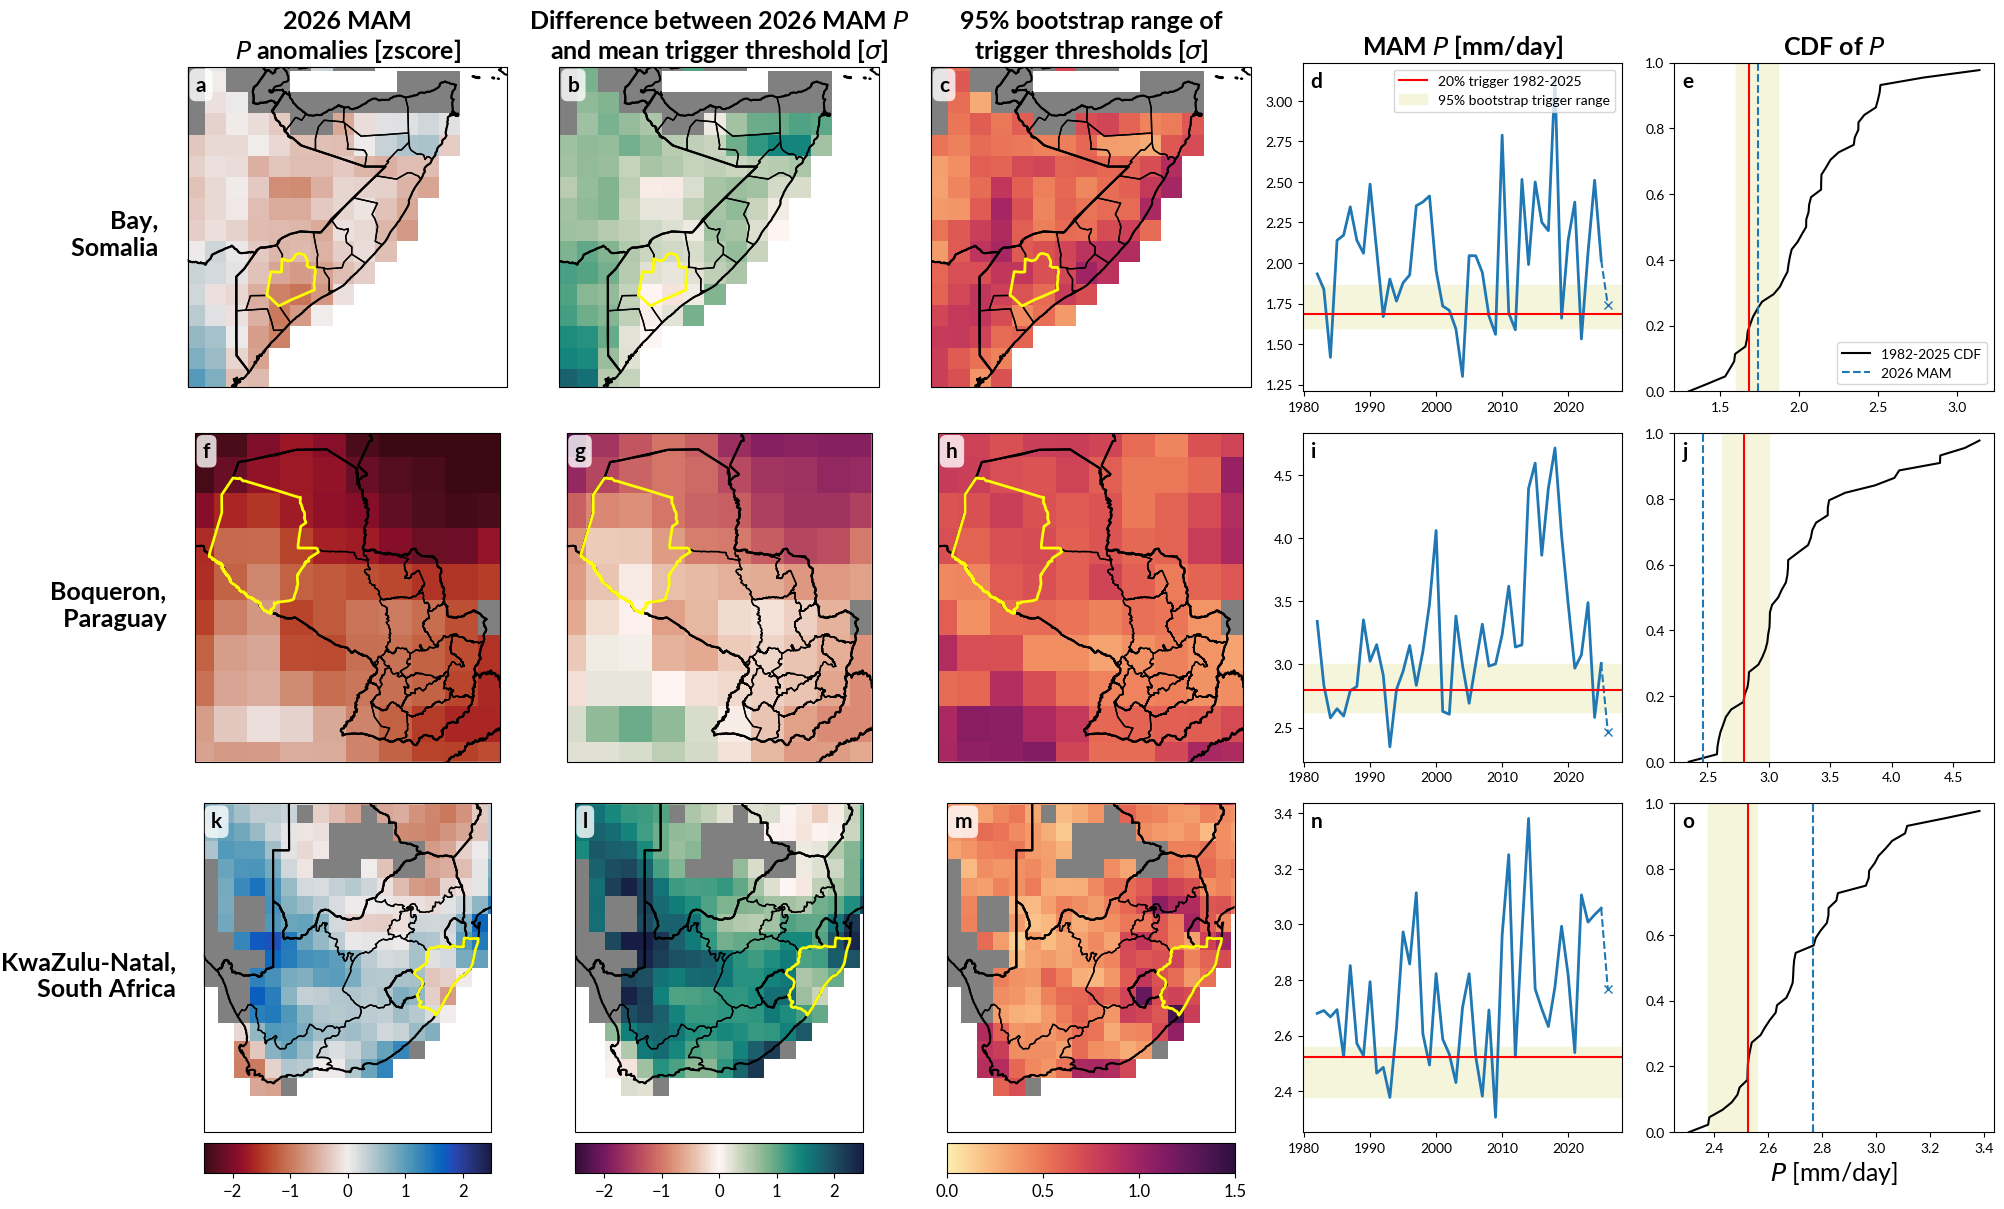

In [11]:
plot_case_study({'Juba':{'lat':2,'lon':43.5}, # possible
                'Chaco':{'lat':-22,'lon':-60}, # clear trigger
                'KZN':{'lat':-30,'lon':30}}, # clear miss
                plot_data_all,
                plot_data_agg,
                adm1,
                dry_seas_mask_color='grey',
                output_fn=dir_list['figs']+'case_studies_2026',
                save_fig = True)


## Somali Reg 2000 case study, in wide format

/home/kschwarz/projects/forecast_uncertainty/2. figures/case_studies_2000_somalireg.pdf saved!
/home/kschwarz/projects/forecast_uncertainty/2. figures/case_studies_2000_somalireg.png saved!


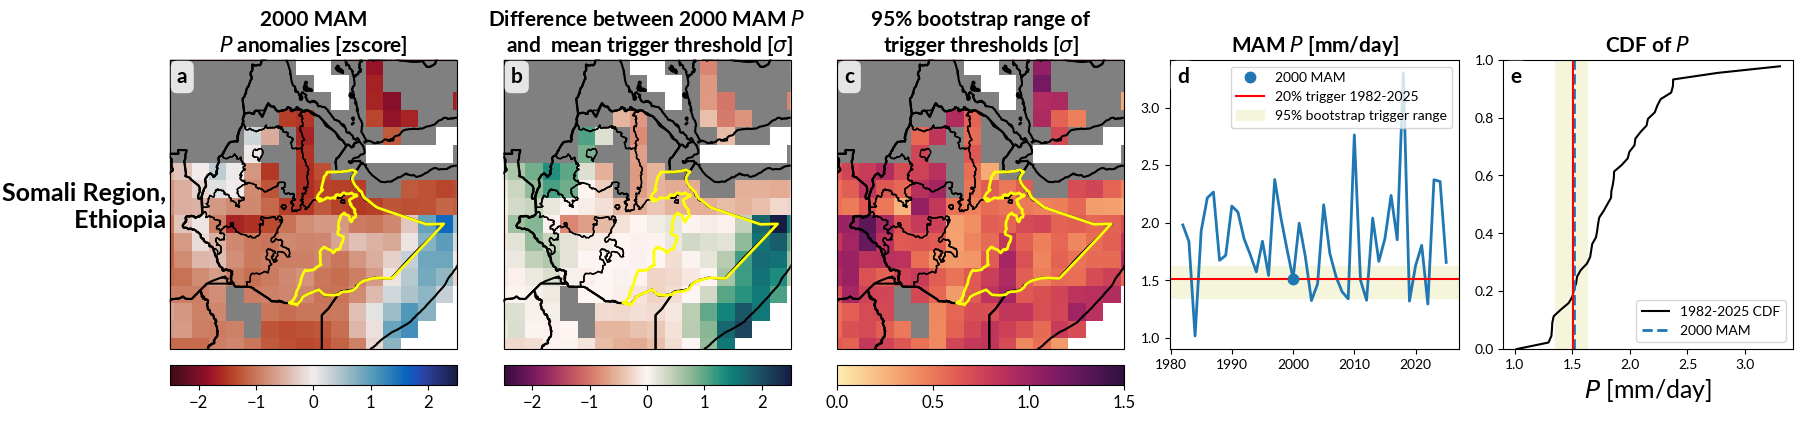

In [12]:
plot_case_study({'Somalireg':{'lat':7,'lon':43}},
                plot_data_all,
                plot_data_agg,
                adm1,
                yr=2000,
                block_length=5,
                dry_seas_mask_color='grey',
                output_fn = dir_list['figs']+'case_studies_2000_somalireg',
                save_fig=True)


## Somali Reg 2021 case study, in wide format, from GPCP
(Have to load GPCP data instead)

In [13]:
# Which data to use
# GPCP, CHIRPS, or NCEP-CFSv2 / NCEP-CFSv2-ensmean
proc_source = 'GPCP'

# Set output filenames
load_fns = {'threshs':dir_list['tmp']+'pr-trigger-threshs_year_'+proc_source+'.zarr',
              'seasmask':dir_list['aux']+'seasmask_CHIRPS.zarr'}

# Load calculated trigger thresholds
threshs = xr.open_zarr(load_fns['threshs'])
threshs['triggrange_bnds'] = xr.concat([threshs['triggthresh'].quantile(0.025,dim='draw'),
                                        threshs['triggthresh'].quantile(0.975,dim='draw')],
                                       dim='bnds')

#-------------------------------------
# Get threshold-based dry season mask
#-------------------------------------
seas_thresh = 0.5 # mm/day

# Load data
dsm = load_data(proc_source,data='seasavg')

# Get boolean mask for threshold exceedence
dry_thresh = dsm.pr.mean('year')>seas_thresh

# Get landmask
landmask = get_landmask(threshs,lm_source='ne110')

# Get country borders
gdf = gpd.read_file(dir_list['aux']+'geo_data/ne_10m_admin_0_countries_iso/ne_10m_admin_0_countries_iso.shp')

# Get mask for if there's an active season locally
active_seasons = xr.open_zarr(load_fns['seasmask'])
# Regrid seasonmask to trigger threshold grid
rgrd = xe.Regridder(active_seasons,threshs,'conservative')
active_seasons_rg = rgrd(active_seasons)
active_seasons_rg = active_seasons_rg.sel(lat=threshs.lat.values)

subset_params = {'lat':slice(-35,35),'lon':slice(-180,180)}

seas_mask = (active_seasons_rg.seasmask.sel(**subset_params) & 
                   dry_thresh).where(landmask).compute()

lat/lon bounds not found in dataset; they will be created.


/home/kschwarz/.conda/envs/aa_thresh/lib/python3.13/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 14.46 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [14]:
plot_data_all = xr.merge([dsm.sel(season='MAM'),
                          # Renamed bnds-edges, otherwise variable is dropped by xagg
          threshs[['triggrange_bnds','triggrange','threshmean']].sel(season='MAM').rename({'bnds':'edges'})],
                         compat='no_conflicts').load().drop_vars(['lat_bnds','lon_bnds','time_bnds'])

In [15]:
wm = xa.pixel_overlaps(plot_data_all,adm1)
with xa.set_options(impl='numba',silent=True):
    plot_data_agg = xa.aggregate(plot_data_all,wm)
    plot_data_agg = plot_data_agg.to_dataset()

    plot_data_agg = plot_data_agg.set_index(poly_idx='adm1_code')

creating polygons for each pixel...
lat/lon bounds not found in dataset; they will be created.
calculating overlaps between pixels and output polygons...
success!


/home/kschwarz/projects/forecast_uncertainty/2. figures/case_studies_2021_somalireg_gpcp.pdf saved!
/home/kschwarz/projects/forecast_uncertainty/2. figures/case_studies_2021_somalireg_gpcp.png saved!


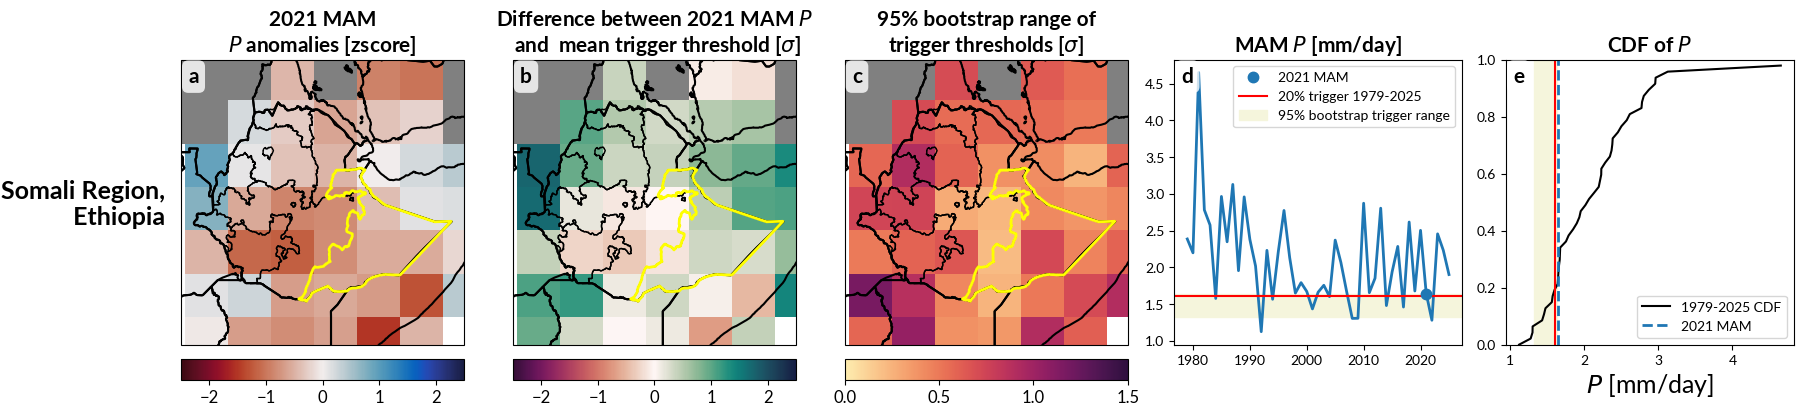

In [28]:
plot_case_study({'Somalireg':{'lat':7,'lon':43}},
                plot_data_all,
                plot_data_agg,
                adm1,
                yr=2021,
                block_length=5,
                dry_seas_mask_color='grey',
                output_fn = dir_list['figs']+'case_studies_2021_somalireg_gpcp',
                save_fig=True)
